THINGS TO CHECK:
- SRP CALC - SOLAR LUMINOSITY VALUE
- SRP AND AERO CALC - ARE POSITIONS AND VELOCITIES RELATIVE?
-

<small>Importing Modules</small>

In [110]:
import os

import numpy as np
from IPython.core.pylabtools import figsize
from PIL.ImageColor import colormap
from astropy.coordinates.matrix_utilities import rotation_matrix
from matplotlib import pyplot as plt
from matplotlib.pyplot import subplots
from matplotlib import rcParams
from scipy.constants import mu_0
from tudatpy import constants
from tudatpy.data import save2txt
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, propagation_setup, simulator
from tudatpy.astro import element_conversion

In [111]:
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 10
rcParams['axes.labelsize'] = 10
rcParams['xtick.labelsize'] = 8
rcParams['ytick.labelsize'] = 8
rcParams['legend.fontsize'] = 9

In [112]:
palette = {
    "pastel_blue"   : "#6AA7FF",
    "pastel_pink"   : "#FF82A9",

    "pastel_green"  : "#7ED6A6",
    "pastel_purple" : "#A894E8",
    "pastel_orange" : "#FFB27C",
    "pastel_teal"   : "#63D2C6"
}

In [113]:
# Retrieve current directory
current_directory = os.getcwd()

# student number: 1244779 --> 1244ABC
A = 4
B = 2
C = 6

In [114]:
simulation_start_epoch = (
    35.4 * constants.JULIAN_YEAR
    + A * 7.0 * constants.JULIAN_DAY
    + B * constants.JULIAN_DAY
    + C * constants.JULIAN_DAY / 24.0
)
simulation_end_epoch = simulation_start_epoch + 344.0 * constants.JULIAN_DAY / 24.0


<small>Create Environment</small>

In [115]:
# Load spice kernels.
spice.load_standard_kernels()
spice.load_kernel(current_directory + "/juice_mat_crema_5_1_150lb_v01.bsp")

# Create settings for celestial bodies
bodies_to_create = ["Ganymede", "Jupiter", "Sun", "Saturn", "Europa", "Io", "Callisto"]
global_frame_origin = "Ganymede"
global_frame_orientation = "ECLIPJ2000"
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation
)

<small> Create Accelerations </small>

<small> Create Vehicle </small>

In [116]:
reference_area = 100.0                                  # m2
drag_coefficient = 1.2
radiation_pressure_coefficient = 1.2                    # kg
density_scale_height = 40e3                             # m
density_at_zero_alt = 2e-9                              # kg/m3

In [117]:
body_settings.add_empty_settings("JUICE")

body_settings.get("Ganymede").atmosphere_settings = environment_setup.atmosphere.exponential(density_at_zero_alt, density_scale_height)

# Create environment
bodies = environment_setup.create_system_of_bodies(body_settings)
bodies.get_body('JUICE').mass = 2000.0

aero_coefficient_settings = environment_setup.aerodynamic_coefficients.constant(reference_area,[drag_coefficient,0.0,0.0])

environment_setup.add_aerodynamic_coefficient_interface(bodies, "JUICE", aero_coefficient_settings)

occulting_bodies = ["Ganymede"]
radiation_pressure_settings = environment_setup.radiation_pressure.cannonball("Sun", reference_area, radiation_pressure_coefficient, occulting_bodies)

environment_setup.add_radiation_pressure_interface(bodies, "JUICE", radiation_pressure_settings)


In [118]:
# Define bodies that are propagated, and their central bodies of propagation.
bodies_to_propagate = ["JUICE"]
central_bodies = ["Ganymede"]



# Define accelerations acting on vehicle.
acceleration_settings_on_vehicle = dict(
    Ganymede =
    [
    propagation_setup.acceleration.spherical_harmonic_gravity(2,2),
    propagation_setup.acceleration.aerodynamic()
    ],

    Jupiter =
    [
    propagation_setup.acceleration.spherical_harmonic_gravity(4,0)
    ],

    Sun =
    [
    propagation_setup.acceleration.point_mass_gravity(),
    propagation_setup.acceleration.cannonball_radiation_pressure()
    ],

    Saturn =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ],

    Europa =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ],

    Io =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ],

    Callisto =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ]
)

# Create global acceleration dictionary.
acceleration_settings = {"JUICE": acceleration_settings_on_vehicle}

# Create acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_settings, bodies_to_propagate, central_bodies
)

<small> Create Propagation Settings </small>

In [119]:
# Define initial state.
system_initial_state = spice.get_body_cartesian_state_at_epoch(
    target_body_name="JUICE",
    observer_body_name="Ganymede",
    reference_frame_name="ECLIPJ2000",
    aberration_corrections="NONE",
    ephemeris_time=simulation_start_epoch,
)

# Define required outputs
# As required by the question dep variable saved in the order: [keplerian elements (6),
#                                                               gravitational acceleration on JUICE due to Ganymede using spherical harmonic gravity (3),
#                                                               gravitational acceleration on JUICE due to Io using point-mass gravity (3),
#                                                               gravitational acceleration on JUICE due to the Sun using point-mass gravity (3),
#                                                               aerodynamic acceleration on JUICE due to Ganymede’s (3),
#                                                               solar radiation pressure acceleration on JUICE due to the Sun - cannonball model, with shadowing by Ganymede (3)
#                                                               altitude of JUICE overtime (1)
#                                                               relative position of JUICE wrt Sun - for aero_acc_manual_calc (3)
##                                                              relative position of JUICE wrt Ganymede - for srp_acc_manual_calc (3)
#                                                               irradiance (1)]
# Total Variables: 29

dependent_variables_to_save = [

    propagation_setup.dependent_variable.keplerian_state("JUICE", "Ganymede"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.spherical_harmonic_gravity_type,"JUICE", "Ganymede"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.point_mass_gravity_type,"JUICE", "Io"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.point_mass_gravity_type,"JUICE", "Sun"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.aerodynamic_type,"JUICE", "Ganymede"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.cannonball_radiation_pressure_type,"JUICE", "Sun"),

    propagation_setup.dependent_variable.altitude("JUICE", "Ganymede"),

    propagation_setup.dependent_variable.relative_position("JUICE", "Sun"),

    propagation_setup.dependent_variable.relative_position("JUICE", "Ganymede"),

    propagation_setup.dependent_variable.received_irradiance("JUICE", "Sun"),

    propagation_setup.dependent_variable.relative_distance("JUICE", "Sun")
]

# Create numerical integrator settings.
fixed_step_size = 10.0
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, coefficient_set=propagation_setup.integrator.CoefficientSets.rk_4
)

# Create propagation settings.
termination_settings = propagation_setup.propagator.time_termination(
    simulation_end_epoch
)
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings,
    output_variables=dependent_variables_to_save,
)

propagator_settings.print_settings.print_initial_and_final_conditions = True

<small> Propagate Orbit </small>

In [120]:
# Create simulation object and propagate dynamics.
dynamics_simulator = simulator.create_dynamics_simulator(
    bodies, propagator_settings
)

# Retrieve all data produced by simulation
propagation_results = dynamics_simulator.propagation_results

# Extract numerical solution for states and dependent variables
state_history = propagation_results.state_history
dependent_variables = propagation_results.dependent_variable_history



<small> Save Results </small>

In [121]:
save2txt(
    solution = state_history, filename="JUICEPropagationHistory_Q1.dat", directory="./"
)

save2txt(
    solution=dependent_variables,
    filename="JUICEPropagationHistory_DependentVariables_Q1.dat",
    directory="./",
)

<small>Extracting Results</small>

In [122]:
# Define required outputs
# As required by the question dep variable saved in the order: [keplerian elements (6),
#                                                               gravitational acceleration on JUICE due to Ganymede using spherical harmonic gravity (3),
#                                                               gravitational acceleration on JUICE due to Io using point-mass gravity (3),
#                                                               gravitational acceleration on JUICE due to the Sun using point-mass gravity (3),
#                                                               aerodynamic acceleration on JUICE due to Ganymede’s (3),
#                                                               solar radiation pressure acceleration on JUICE due to the Sun - cannonball model, with shadowing by Ganymede (3)
#                                                               altitude of JUICE overtime (1)
#                                                               relative position of JUICE wrt Sun - for aero_acc_manual_calc (3)
##                                                              relative position of JUICE wrt Ganymede - for srp_acc_manual_calc (3)
#                                                               irradiance (1)
#                                                               relative distance of JUICE wrt Sun (1)] 

# Total Variables: 30

result = np.vstack(list(dependent_variables.values()))

keplerian_elements_JUICE = result[:, 0:6]
grav_acc_JUICE_Ganymede = result[:, 6:9]
grav_acc_JUICE_Io = result[:, 9:12]
grav_acc_JUICE_Sun = result[:, 12:15]
aero_acc_JUICE_Ganymede = result[:, 15:18]
srp_acc_JUICE_Sun = result[:, 18:21]
altitude_JUICE = result[:, 21]
r_JUICE_Sun = result[:, 22:25]
r_JUICE_Ganymede = result[:, 25:28]
irradiance = result[:, 28:29]
d_JUICE_Sun = result[:, 29:30]


time = dependent_variables.keys()
time_days = [
    t / constants.JULIAN_DAY - simulation_start_epoch / constants.JULIAN_DAY
    for t in time
]

print(altitude_JUICE[0])


518382.1329124444


In [138]:
print(bodies.get_body("Ganymede").atmosphere_model)

<small>  Provide the mathematical expressions of the aerodynamic and radia
tion pressure accelerations. Use these to choose dependent variables
to add to the simulation, such that you can manually compute the ac
celerations, and compare against the saved acceleration vectors. Use
these results to generate a figure validating both the direction and
magnitude of the radiation pressure and aerodynamic accelerations.
Briefly explain if/why you think your results verify the implementa
tion. </small>

In [123]:
reference_area = 100.0                                  # m2
drag_coefficient = 1.2
radiation_pressure_coefficient = 1.2                    # kg
density_scale_height = 40e3                             # m
density_at_zero_alt = 2e-9                              # kg/m3


solar_luminosity = 4 * np.pi * r_JUICE_Sun**2 * irradiance
print(solar_luminosity.shape)
irradiance.shape


(123841, 3)


(123841, 1)

In [124]:
from tudatpy.astro.frame_conversion import inertial_to_body_fixed_rotation_matrix, inertial_to_rsw_rotation_matrix
# MANUAL
x_c_num = np.vstack(list(state_history.values()))


r_vec = r_JUICE_Sun
print(r_vec.shape)

srp_acc_JUICE_Sun_manual = np.zeros_like(srp_acc_JUICE_Sun)
aero_acc_JUICE_Ganymede_manual = np.zeros_like(aero_acc_JUICE_Ganymede)
# density = np.zeros(len(time_days))

for time_step in range(len(r_vec)):
    # Aerodynamic acceleration
    density = density_at_zero_alt * np.exp(-altitude_JUICE[time_step]/density_scale_height)
    w_G = bodies.get_body("Ganymede").rotation_model.angular_velocity_in_inertial_frame(time_days[time_step]*constants.JULIAN_DAY) 
    v_air = x_c_num[time_step,3:6] - np.cross(w_G, r_JUICE_Ganymede[time_step])
    aero_acc_JUICE_Ganymede_manual[time_step] = - 0.5 * density * np.linalg.norm(v_air) * v_air * reference_area * drag_coefficient / bodies.get_body('JUICE').mass 
    

    # Radiation pressure acceleration
    # srp_acc_JUICE_Sun_manual[time_step] = -solar_luminosity[ time_step] / (4 * np.pi * constants.SPEED_OF_LIGHT) * (radiation_pressure_coefficient * reference_area / bodies.get_body('JUICE').mass ) * r_vec[time_step]/ np.linalg.norm(r_vec[time_step]) ** 3
    srp_acc_JUICE_Sun_manual[time_step] = irradiance[time_step] * radiation_pressure_coefficient * reference_area * r_vec[time_step]/(constants.SPEED_OF_LIGHT * bodies.get_body('JUICE').mass * np.linalg.norm(r_vec[time_step]))
    

aero_residual = aero_acc_JUICE_Ganymede - aero_acc_JUICE_Ganymede_manual


(123841, 3)


In [125]:
time_state = np.array(list(state_history.keys()))
time_days_state = (time_state - simulation_start_epoch) / constants.JULIAN_DAY
print(np.max(np.linalg.norm(aero_acc_JUICE_Ganymede_manual, axis=1)))

2.3412867934914527e-09


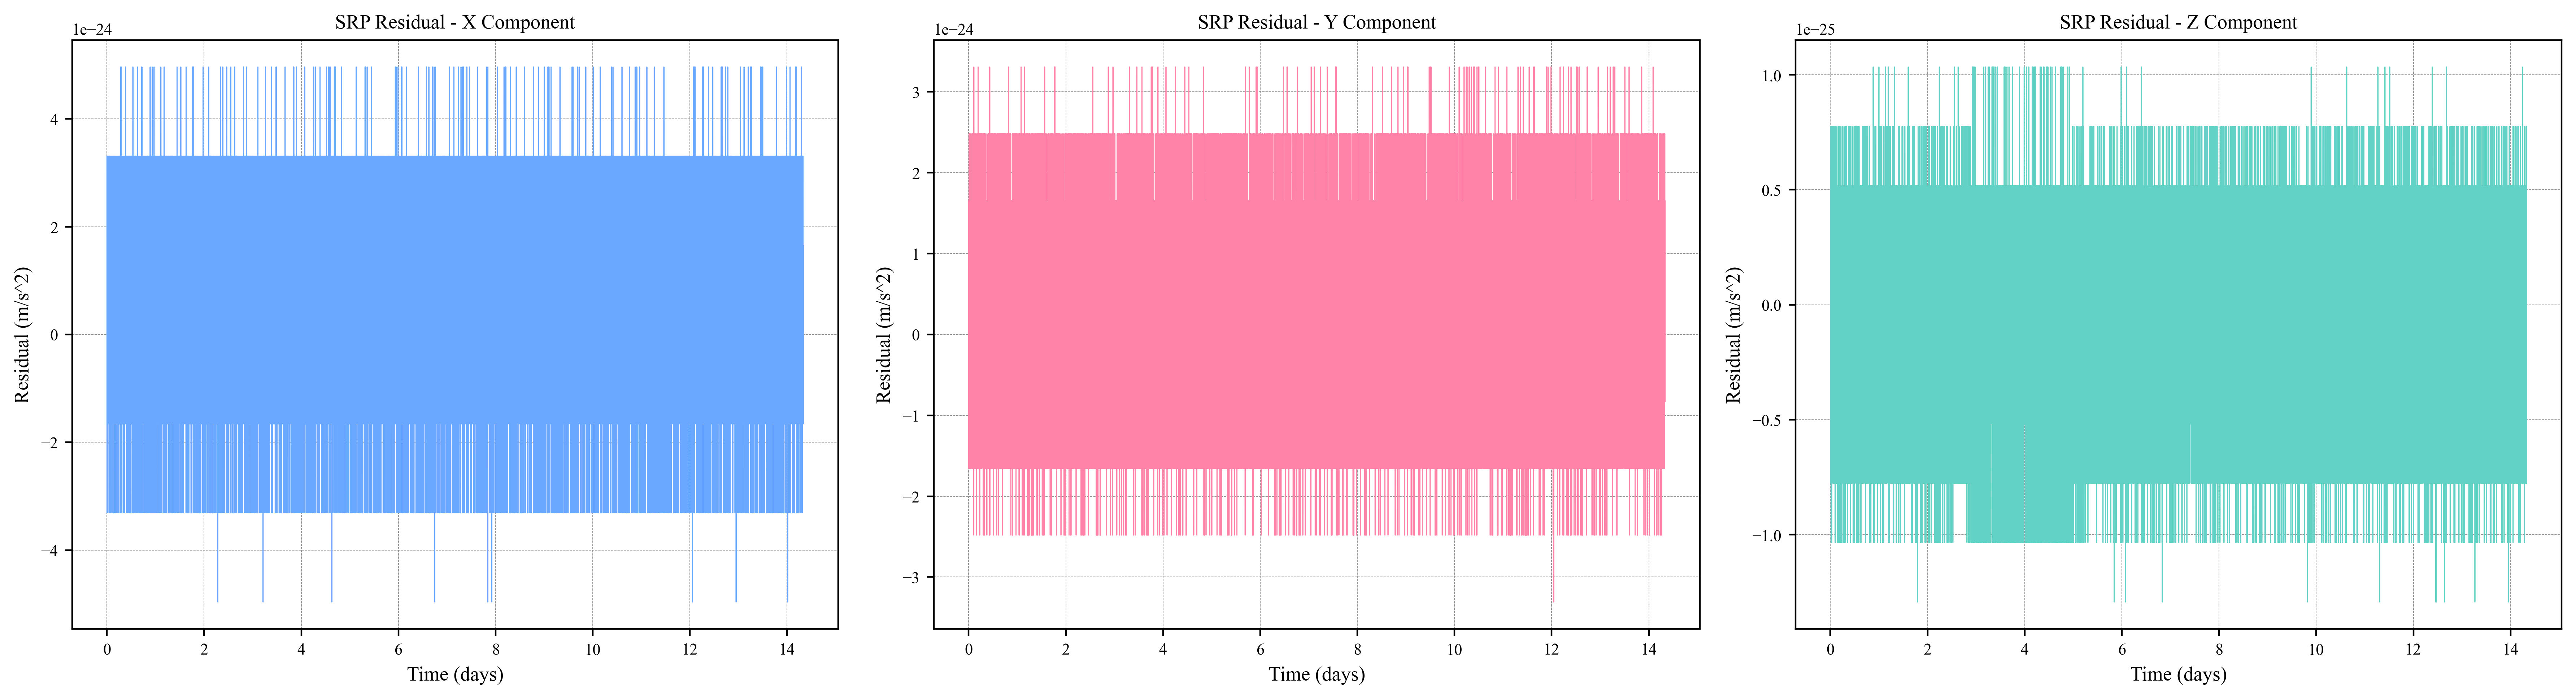

In [126]:
# Compute residuals
srp_residual =   srp_acc_JUICE_Sun -srp_acc_JUICE_Sun_manual 
print()

# Create 1x3 subplot
fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=400)

# X component
ax[0].plot(time_days_state, srp_residual[:, 0], color=palette["pastel_blue"], linewidth = 0.5)
ax[0].set_xlabel("Time (days)")
ax[0].set_ylabel("Residual (m/s^2)")
ax[0].set_title("SRP Residual - X Component")
ax[0].grid(True, color = 'gray', linewidth = 0.3, linestyle = '--')


# Y component
ax[1].plot(time_days_state, srp_residual[:, 1], color=palette["pastel_pink"], linewidth = 0.5)
ax[1].set_xlabel("Time (days)")
ax[1].set_ylabel("Residual (m/s^2)")
ax[1].set_title("SRP Residual - Y Component")
ax[1].grid(True, color = 'gray', linewidth = 0.3, linestyle = '--')

# Z component
ax[2].plot(time_days_state, srp_residual[:, 2], color = palette["pastel_teal"], linewidth = 0.5)
ax[2].set_xlabel("Time (days)")
ax[2].set_ylabel("Residual (m/s^2)")
ax[2].set_title("SRP Residual - Z Component")
ax[2].grid(True, color = 'gray', linewidth = 0.3, linestyle = '--')

plt.tight_layout()
plt.show()

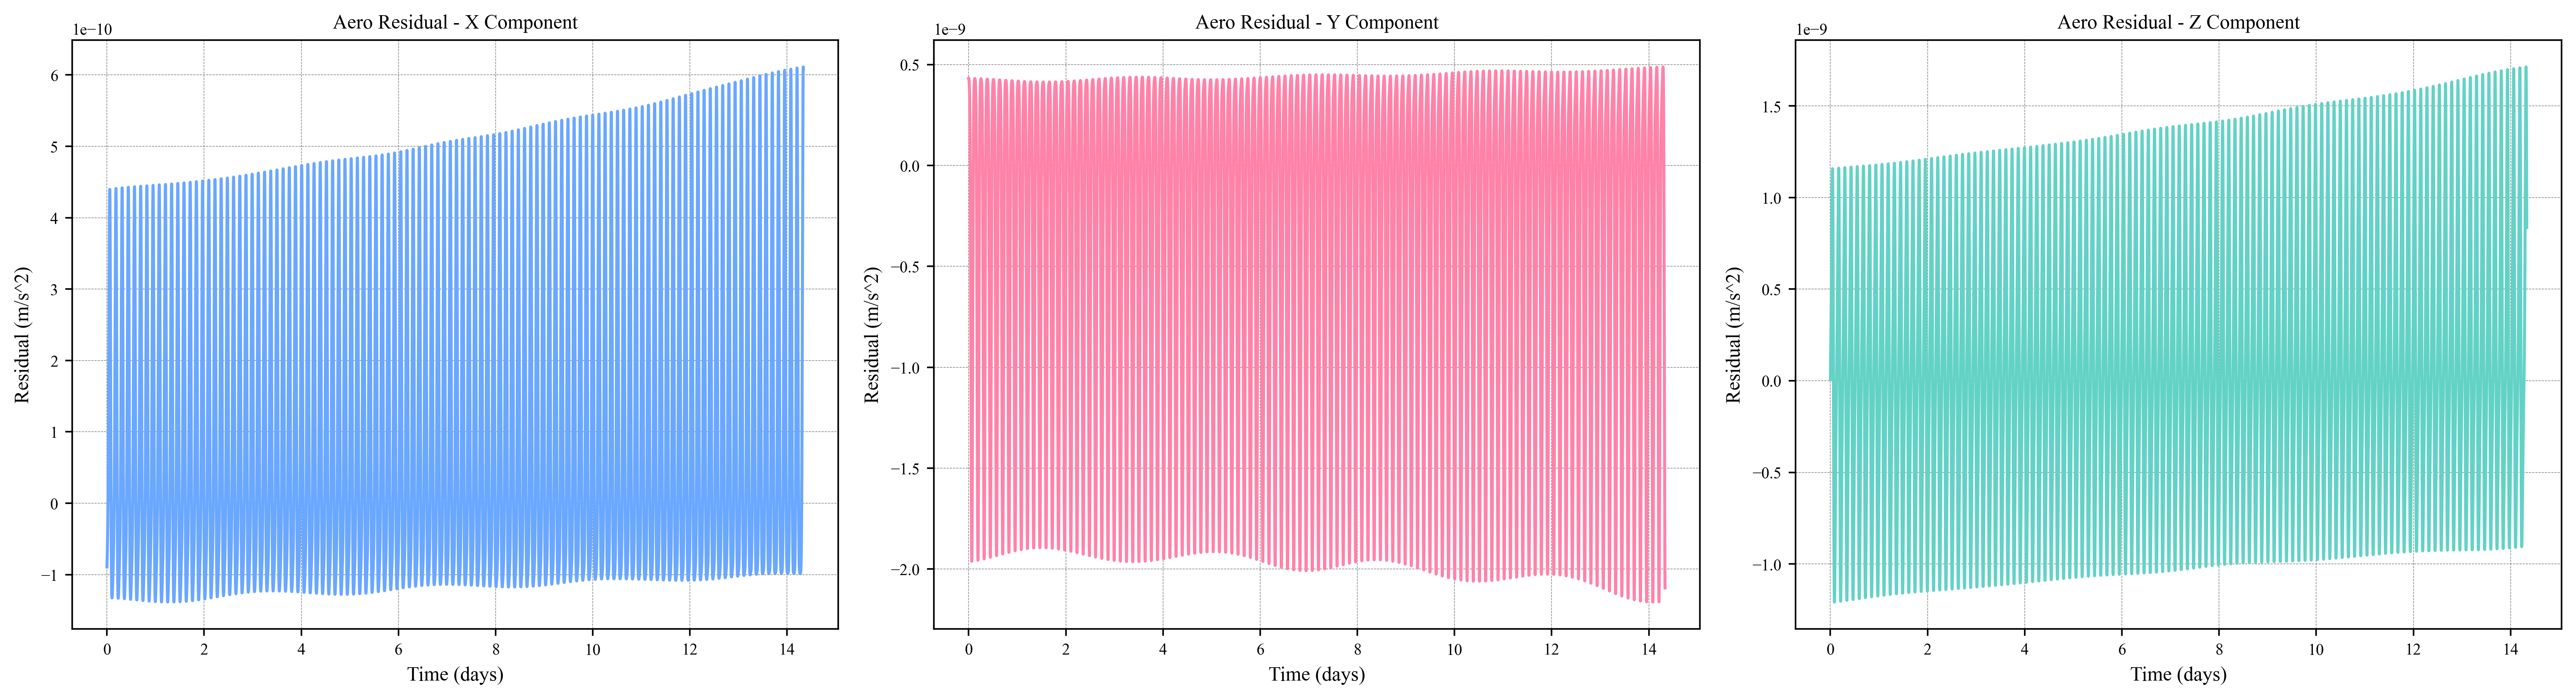

In [127]:
# Compute residuals
aero_residual = aero_acc_JUICE_Ganymede - aero_acc_JUICE_Ganymede_manual

# Create 1x3 subplot
fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=400)

# X component
ax[0].plot(time_days_state, aero_residual[:, 0], color=palette["pastel_blue"])
ax[0].set_xlabel("Time (days)")
ax[0].set_ylabel("Residual (m/s^2)")
ax[0].set_title("Aero Residual - X Component")
ax[0].grid(True, color = 'gray', linewidth = 0.3, linestyle = '--')

# Y component
ax[1].plot(time_days_state, aero_residual[:, 1], color=palette["pastel_pink"])
ax[1].set_xlabel("Time (days)")
ax[1].set_ylabel("Residual (m/s^2)")
ax[1].set_title("Aero Residual - Y Component")
ax[1].grid(True, color = 'gray', linewidth = 0.3, linestyle = '--')

# Z component
ax[2].plot(time_days_state, aero_residual[:, 2], color=palette["pastel_teal"])
ax[2].set_xlabel("Time (days)")
ax[2].set_ylabel("Residual (m/s^2)")
ax[2].set_title("Aero Residual - Z Component")
ax[2].grid(True, color = 'gray', linewidth = 0.3, linestyle = '--')


plt.tight_layout()
plt.show()

In [139]:
time_state = np.array(list(state_history.keys()))
time_days_state = (time_state - simulation_start_epoch) / constants.JULIAN_DAY
a_aero_rsw = np.zeros_like(aero_acc_JUICE_Ganymede_manual)
a_srp_rsw = np.zeros_like(srp_acc_JUICE_Sun_manual)

for time_step in range(len(x_c_num)):
    # Finding the rotation matrix
    C_i_to_rsw = inertial_to_rsw_rotation_matrix(x_c_num[time_step])

    # Converting to RSW frame of reference for both
    a_aero_rsw[time_step] = C_i_to_rsw @ aero_acc_JUICE_Ganymede_manual[time_step]
    a_srp_rsw[time_step] =  C_i_to_rsw @ srp_acc_JUICE_Sun_manual[time_step]

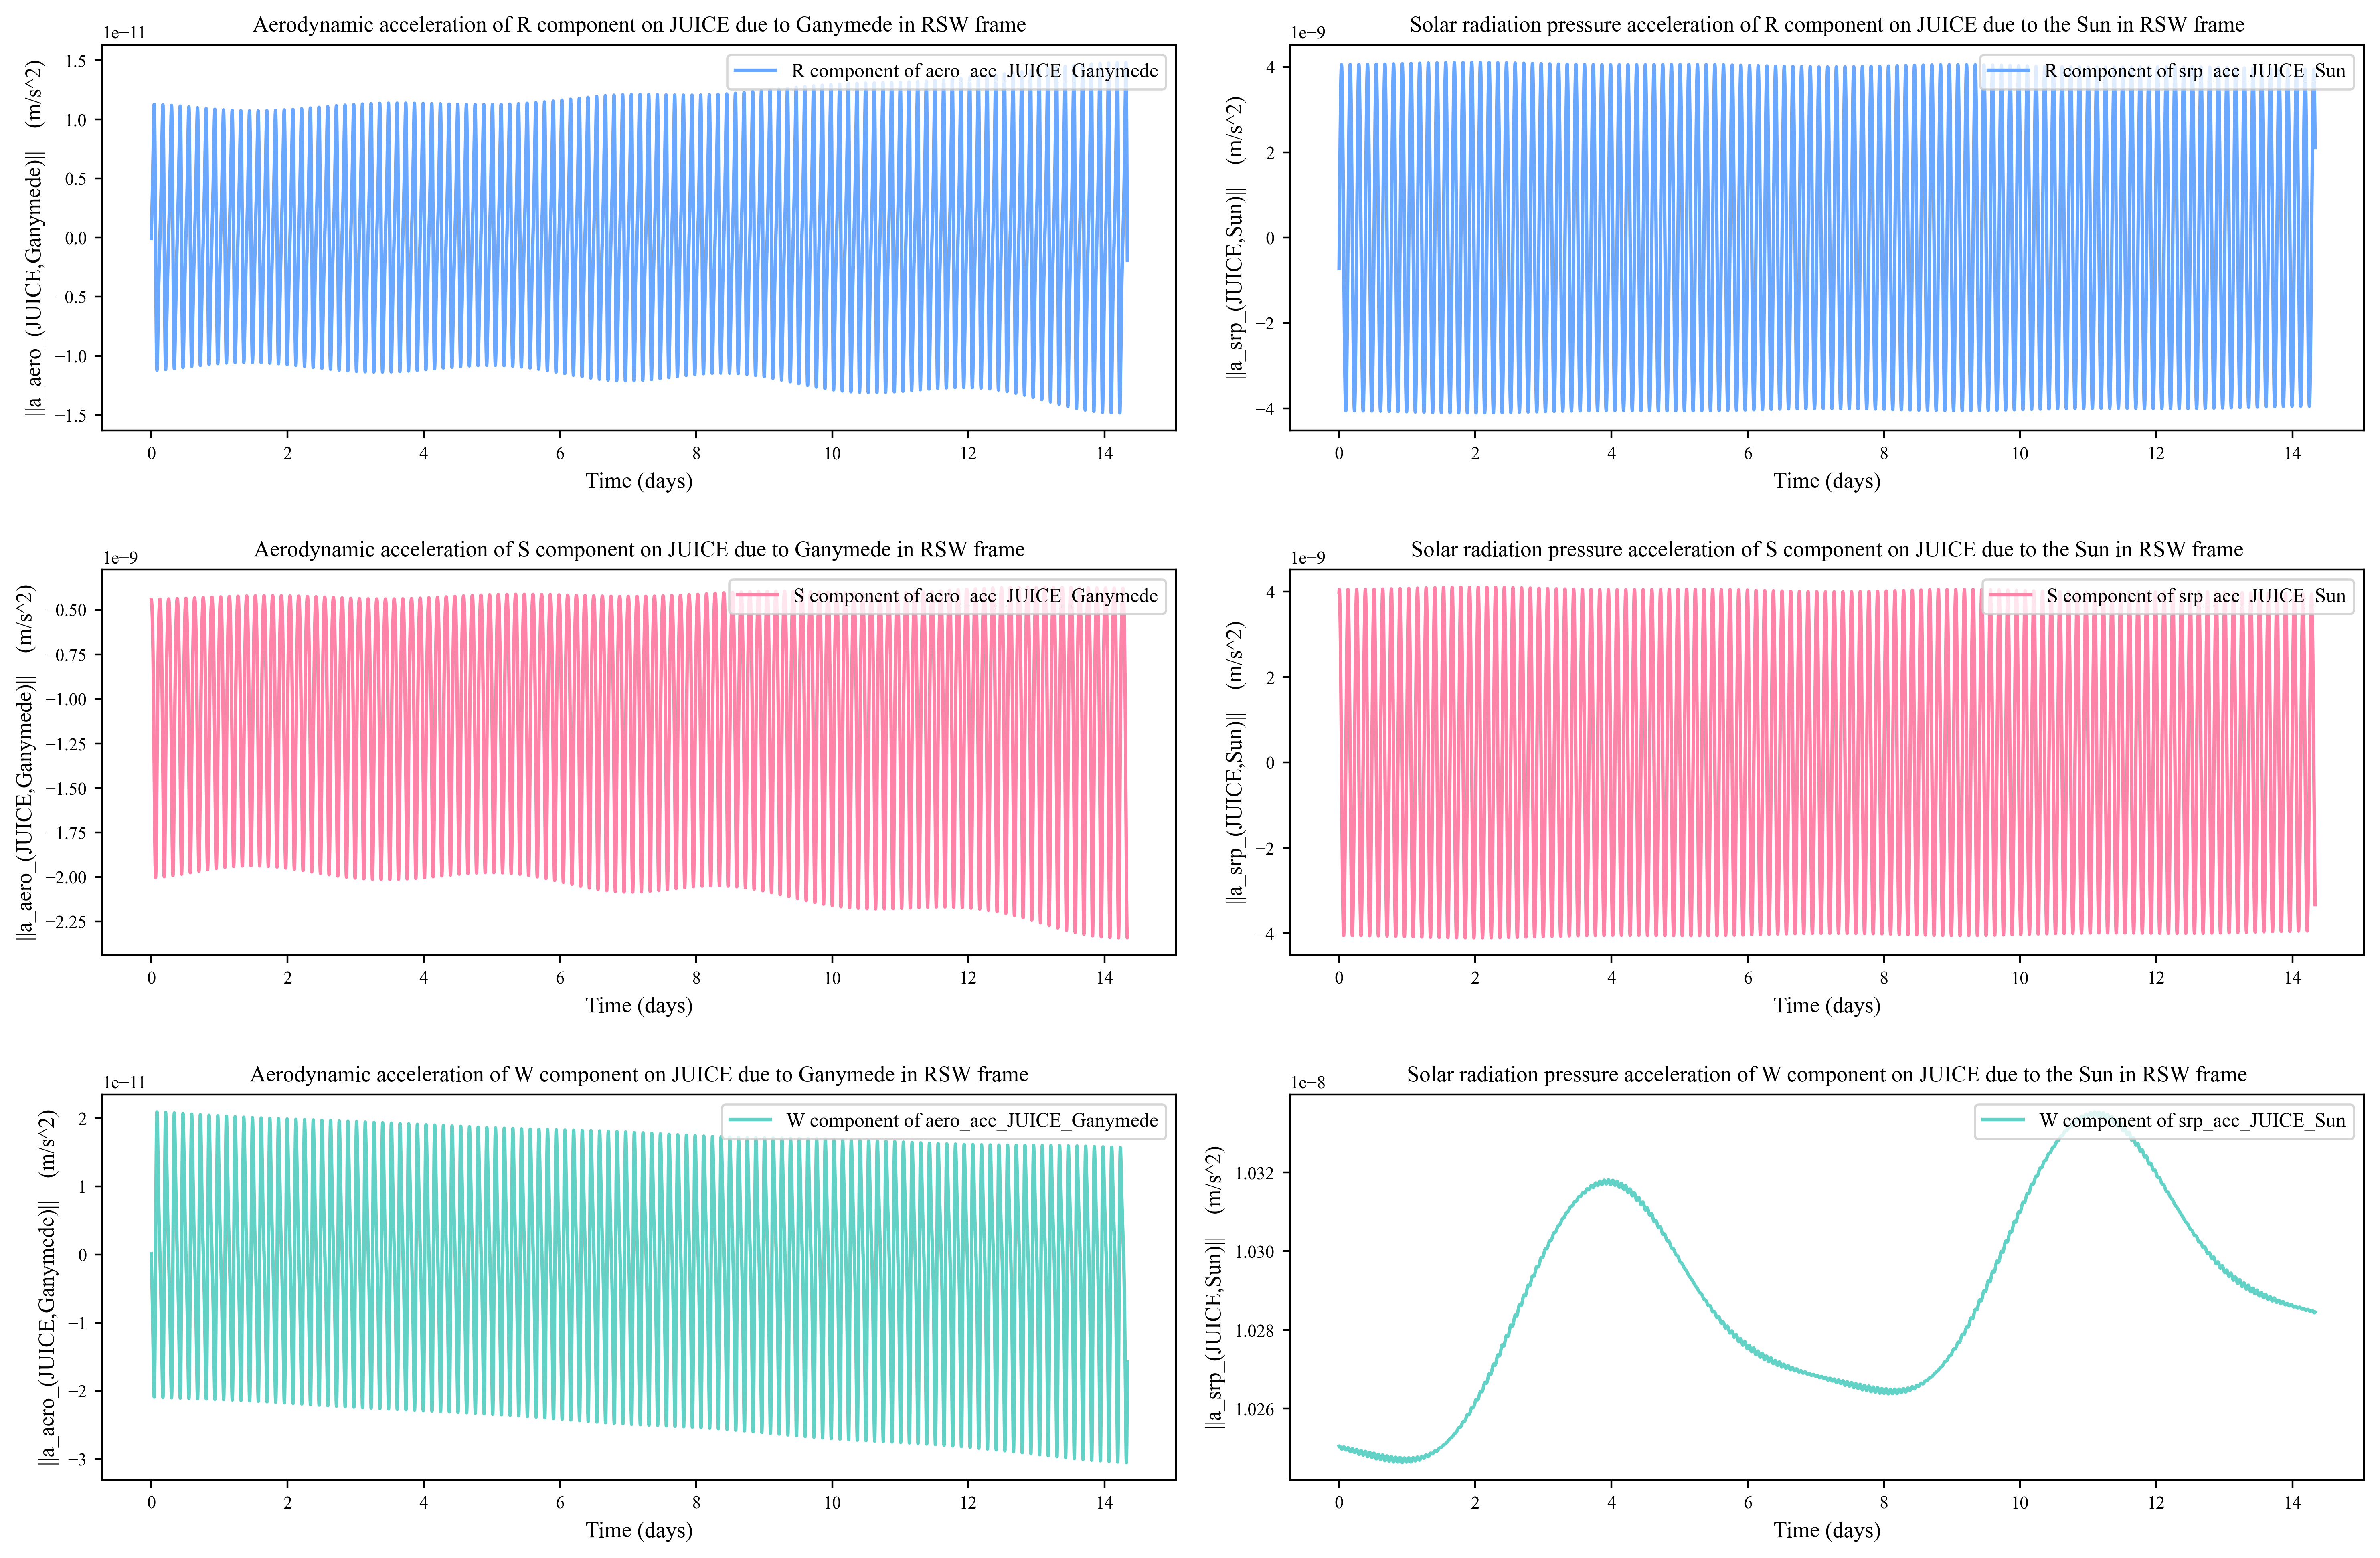

In [141]:

fig,ax = plt.subplots(3,2, figsize = (15,10), dpi = 400)
ax[0,0].plot(time_days_state, a_aero_rsw[:, 0], label = "R component of aero_acc_JUICE_Ganymede", color = palette["pastel_blue"])
ax[0,0].set_xlabel("Time (days)")
ax[0,0].set_ylabel("||a_aero_(JUICE,Ganymede)||    (m/s^2)")
ax[0,0].set_title("Aerodynamic acceleration of R component on JUICE due to Ganymede in RSW frame")
ax[0,0].legend(loc = "upper right")


ax[1,0].plot(time_days_state, a_aero_rsw[:, 1], label = "S component of aero_acc_JUICE_Ganymede", color = palette["pastel_pink"])
ax[1,0].set_xlabel("Time (days)")
ax[1,0].set_ylabel("||a_aero_(JUICE,Ganymede)||    (m/s^2)")
ax[1,0].set_title("Aerodynamic acceleration of S component on JUICE due to Ganymede in RSW frame")
ax[1,0].legend( loc = "upper right")

ax[2,0].plot(time_days_state, a_aero_rsw[:, 2], label = "W component of aero_acc_JUICE_Ganymede", color = palette["pastel_teal"])
ax[2,0].set_xlabel("Time (days)")
ax[2,0].set_ylabel("||a_aero_(JUICE,Ganymede)||    (m/s^2)")
ax[2,0].set_title("Aerodynamic acceleration of W component on JUICE due to Ganymede in RSW frame")
ax[2,0].legend(loc = "upper right")

ax[0,1].plot(time_days_state, a_srp_rsw[:, 0], label = "R component of srp_acc_JUICE_Sun", color = palette["pastel_blue"])
ax[0,1].set_xlabel("Time (days)")
ax[0,1].set_ylabel("||a_srp_(JUICE,Sun)||    (m/s^2)")
ax[0,1].set_title("Solar radiation pressure acceleration of R component on JUICE due to the Sun in RSW frame")
ax[0,1].legend(loc = "upper right")

ax[1,1].plot(time_days_state, a_srp_rsw[:, 1], label = "S component of srp_acc_JUICE_Sun", color = palette["pastel_pink"])
ax[1,1].set_xlabel("Time (days)")
ax[1,1].set_ylabel("||a_srp_(JUICE,Sun)||    (m/s^2)")
ax[1,1].set_title("Solar radiation pressure acceleration of S component on JUICE due to the Sun in RSW frame")
ax[1,1].legend(loc = "upper right")

ax[2,1].plot(time_days_state, a_srp_rsw[:, 2], label = "W component of srp_acc_JUICE_Sun", color = palette["pastel_teal"])
ax[2,1].set_xlabel("Time (days)")
ax[2,1].set_ylabel("||a_srp_(JUICE,Sun)||    (m/s^2)")
ax[2,1].set_title("Solar radiation pressure acceleration of W component on JUICE due to the Sun in RSW frame")
ax[2,1].legend(loc = "upper right")

plt.tight_layout()
plt.show()


<small>
(c) Perform two additional propagations, turning off the aerodynamic
acceleration in one, and turning off the radiation pressure in the
other.<br>
i For both cases, plot the difference in three-dimensional positions
||∆rG,s(t)|| w.r.t. the nominal propagation. <br>
ii Explain why (relative to the magnitude of the acceleration) the
aerodynamic acceleration has a much stronger impact on the po
sition of the spacecraft than the radiation pressure acceleration.
Use the figures you have made in 3b in your answer.
</small>

In [179]:
def setting_accelerations(aero_acc_on = True, srp_on = True):

    local_body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation
)

    local_body_settings.add_empty_settings("JUICE")

    local_body_settings.get("Ganymede").atmosphere_settings = environment_setup.atmosphere.exponential(density_at_zero_alt, density_scale_height)

    # Create environment
    bodies = environment_setup.create_system_of_bodies(local_body_settings)
    bodies.get_body('JUICE').mass = 2000.0
    if aero_acc_on == True:
        aero_coefficient_settings = environment_setup.aerodynamic_coefficients.constant(reference_area,[drag_coefficient,0.0,0.0])
        environment_setup.add_aerodynamic_coefficient_interface(bodies, "JUICE", aero_coefficient_settings)

    if srp_on == True:
        occulting_bodies = ["Ganymede"]
        radiation_pressure_settings = environment_setup.radiation_pressure.cannonball("Sun", reference_area, radiation_pressure_coefficient, occulting_bodies)
        environment_setup.add_radiation_pressure_interface(bodies, "JUICE", radiation_pressure_settings)



    acceleration_settings_on_vehicle = {
        'Ganymede':
            [
                propagation_setup.acceleration.spherical_harmonic_gravity(2, 2),
            ],

        'Jupiter':
            [
                propagation_setup.acceleration.spherical_harmonic_gravity(4, 0),
            ],

        'Sun':
            [
                propagation_setup.acceleration.point_mass_gravity(),
            ],

        'Saturn':
            [
                propagation_setup.acceleration.point_mass_gravity()
            ],

        'Europa':
            [
                propagation_setup.acceleration.point_mass_gravity()
            ],

        'Io':
            [
                propagation_setup.acceleration.point_mass_gravity()
            ],

        'Callisto':
            [
                propagation_setup.acceleration.point_mass_gravity()
            ]
    }

    if aero_acc_on == True: acceleration_settings_on_vehicle['Ganymede'].append(propagation_setup.acceleration.aerodynamic())
    if srp_on == True: acceleration_settings_on_vehicle['Sun'].append(propagation_setup.acceleration.cannonball_radiation_pressure())

    return bodies, acceleration_settings_on_vehicle

In [191]:
def propagate(bodies, acceleration_settings_on_vehicle):
    
    # Create global acceleration dictionary.
    acceleration_settings = {"JUICE": acceleration_settings_on_vehicle}
    
    # Create acceleration models.
    acceleration_models = propagation_setup.create_acceleration_models(bodies, acceleration_settings, bodies_to_propagate, central_bodies)

    # Define initial state.
    system_initial_state = spice.get_body_cartesian_state_at_epoch(
        target_body_name="JUICE",
        observer_body_name="Ganymede",
        reference_frame_name="ECLIPJ2000",
        aberration_corrections="NONE",
        ephemeris_time=simulation_start_epoch,
    )

    # Define required outputs
    # As required by the question dep variable saved in the order: [keplerian elements (6),
    #                                                               gravitational acceleration on JUICE due to Ganymede using spherical harmonic gravity (3),
    #                                                               gravitational acceleration on JUICE due to Io using point-mass gravity (3),
    #                                                               gravitational acceleration on JUICE due to the Sun using point-mass gravity (3),
    #                                                               aerodynamic acceleration on JUICE due to Ganymede’s (3),
    #                                                               solar radiation pressure acceleration on JUICE due to the Sun - cannonball model, with shadowing by Ganymede (3)
    #                                                               altitude of JUICE overtime (1)
    #                                                               relative position of JUICE wrt Sun - for aero_acc_manual_calc (3)
    ##                                                              relative position of JUICE wrt Ganymede - for srp_acc_manual_calc (3)
    #                                                               irradiance (1)]
    # Total Variables: 29

    dependent_variables_to_save = [
        propagation_setup.dependent_variable.relative_position("JUICE", "Ganymede"),
    ]

    # Create numerical integrator settings.
    fixed_step_size = 10.0
    integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
        fixed_step_size, coefficient_set=propagation_setup.integrator.CoefficientSets.rk_4
    )

    # Create propagation settings.
    termination_settings = propagation_setup.propagator.time_termination(
        simulation_end_epoch
    )
    propagator_settings = propagation_setup.propagator.translational(
        central_bodies,
        acceleration_models,
        bodies_to_propagate,
        system_initial_state,
        simulation_start_epoch,
        integrator_settings,
        termination_settings,
        output_variables=dependent_variables_to_save,
    )

    propagator_settings.print_settings.print_initial_and_final_conditions = True

    # Create simulation object and propagate dynamics.
    dynamics_simulator = simulator.create_dynamics_simulator(
        bodies, propagator_settings
    )

    # Retrieve all data produced by simulation
    propagation_results = dynamics_simulator.propagation_results

    # Extract numerical solution for states and dependent variables
    state_history = propagation_results.state_history
    dependent_variables = propagation_results.dependent_variable_history

    save2txt(
    solution = state_history, filename="JUICEPropagationHistory_Q1.dat", directory="./"
    )

    save2txt(
        solution=dependent_variables,
        filename="JUICEPropagationHistory_DependentVariables_Q1.dat",
        directory="./",
    )

    result = np.vstack(list(dependent_variables.values()))

    time = dependent_variables.keys()
    time_days = [
        t / constants.JULIAN_DAY - simulation_start_epoch / constants.JULIAN_DAY
        for t in time
    ]

    print(result.shape)

    # cartesian_elements = np.zeros((len(time_days), 6))
    # for i in range(len(time_days)):
    #     cartesian_elements[i] = element_conversion.keplerian_to_cartesian(result[i,:6].reshape(6,1), bodies.get_body("Ganymede").gravitational_parameter)

    return {
            'r': result[:, 0:3],
            'time': time,
            'time_days': time_days,
    }


In [198]:
bodies_nom, acceleration_settings_on_vehicle_nom = setting_accelerations(aero_acc_on=True, srp_on=True)
results_nominal_case = propagate(bodies_nom, acceleration_settings_on_vehicle_nom)

    
bodies_aero, acceleration_settings_on_vehicle_aero = setting_accelerations(aero_acc_on=True, srp_on=False)
results_aero_case = propagate(bodies_aero, acceleration_settings_on_vehicle_aero)



acceleration_settings_on_vehicle_srp = setting_accelerations(aero_acc_on=False, srp_on=True)
bodies_srp, acceleration_settings_on_vehicle_srp = acceleration_settings_on_vehicle_srp
results_srp_case = propagate(bodies_srp, acceleration_settings_on_vehicle_srp)



(123841, 3)
(123841, 3)
(123841, 3)


In [193]:
print(results_nominal_case['r'][10])
print(results_aero_case['r'][10])
print(results_srp_case['r'][10])

[ -346152.38503803   152937.17125191 -3126760.31523063]
[ -346152.38503803   152937.17125191 -3126760.31523063]
[ -346152.38508428   152937.17122199 -3126760.31522947]


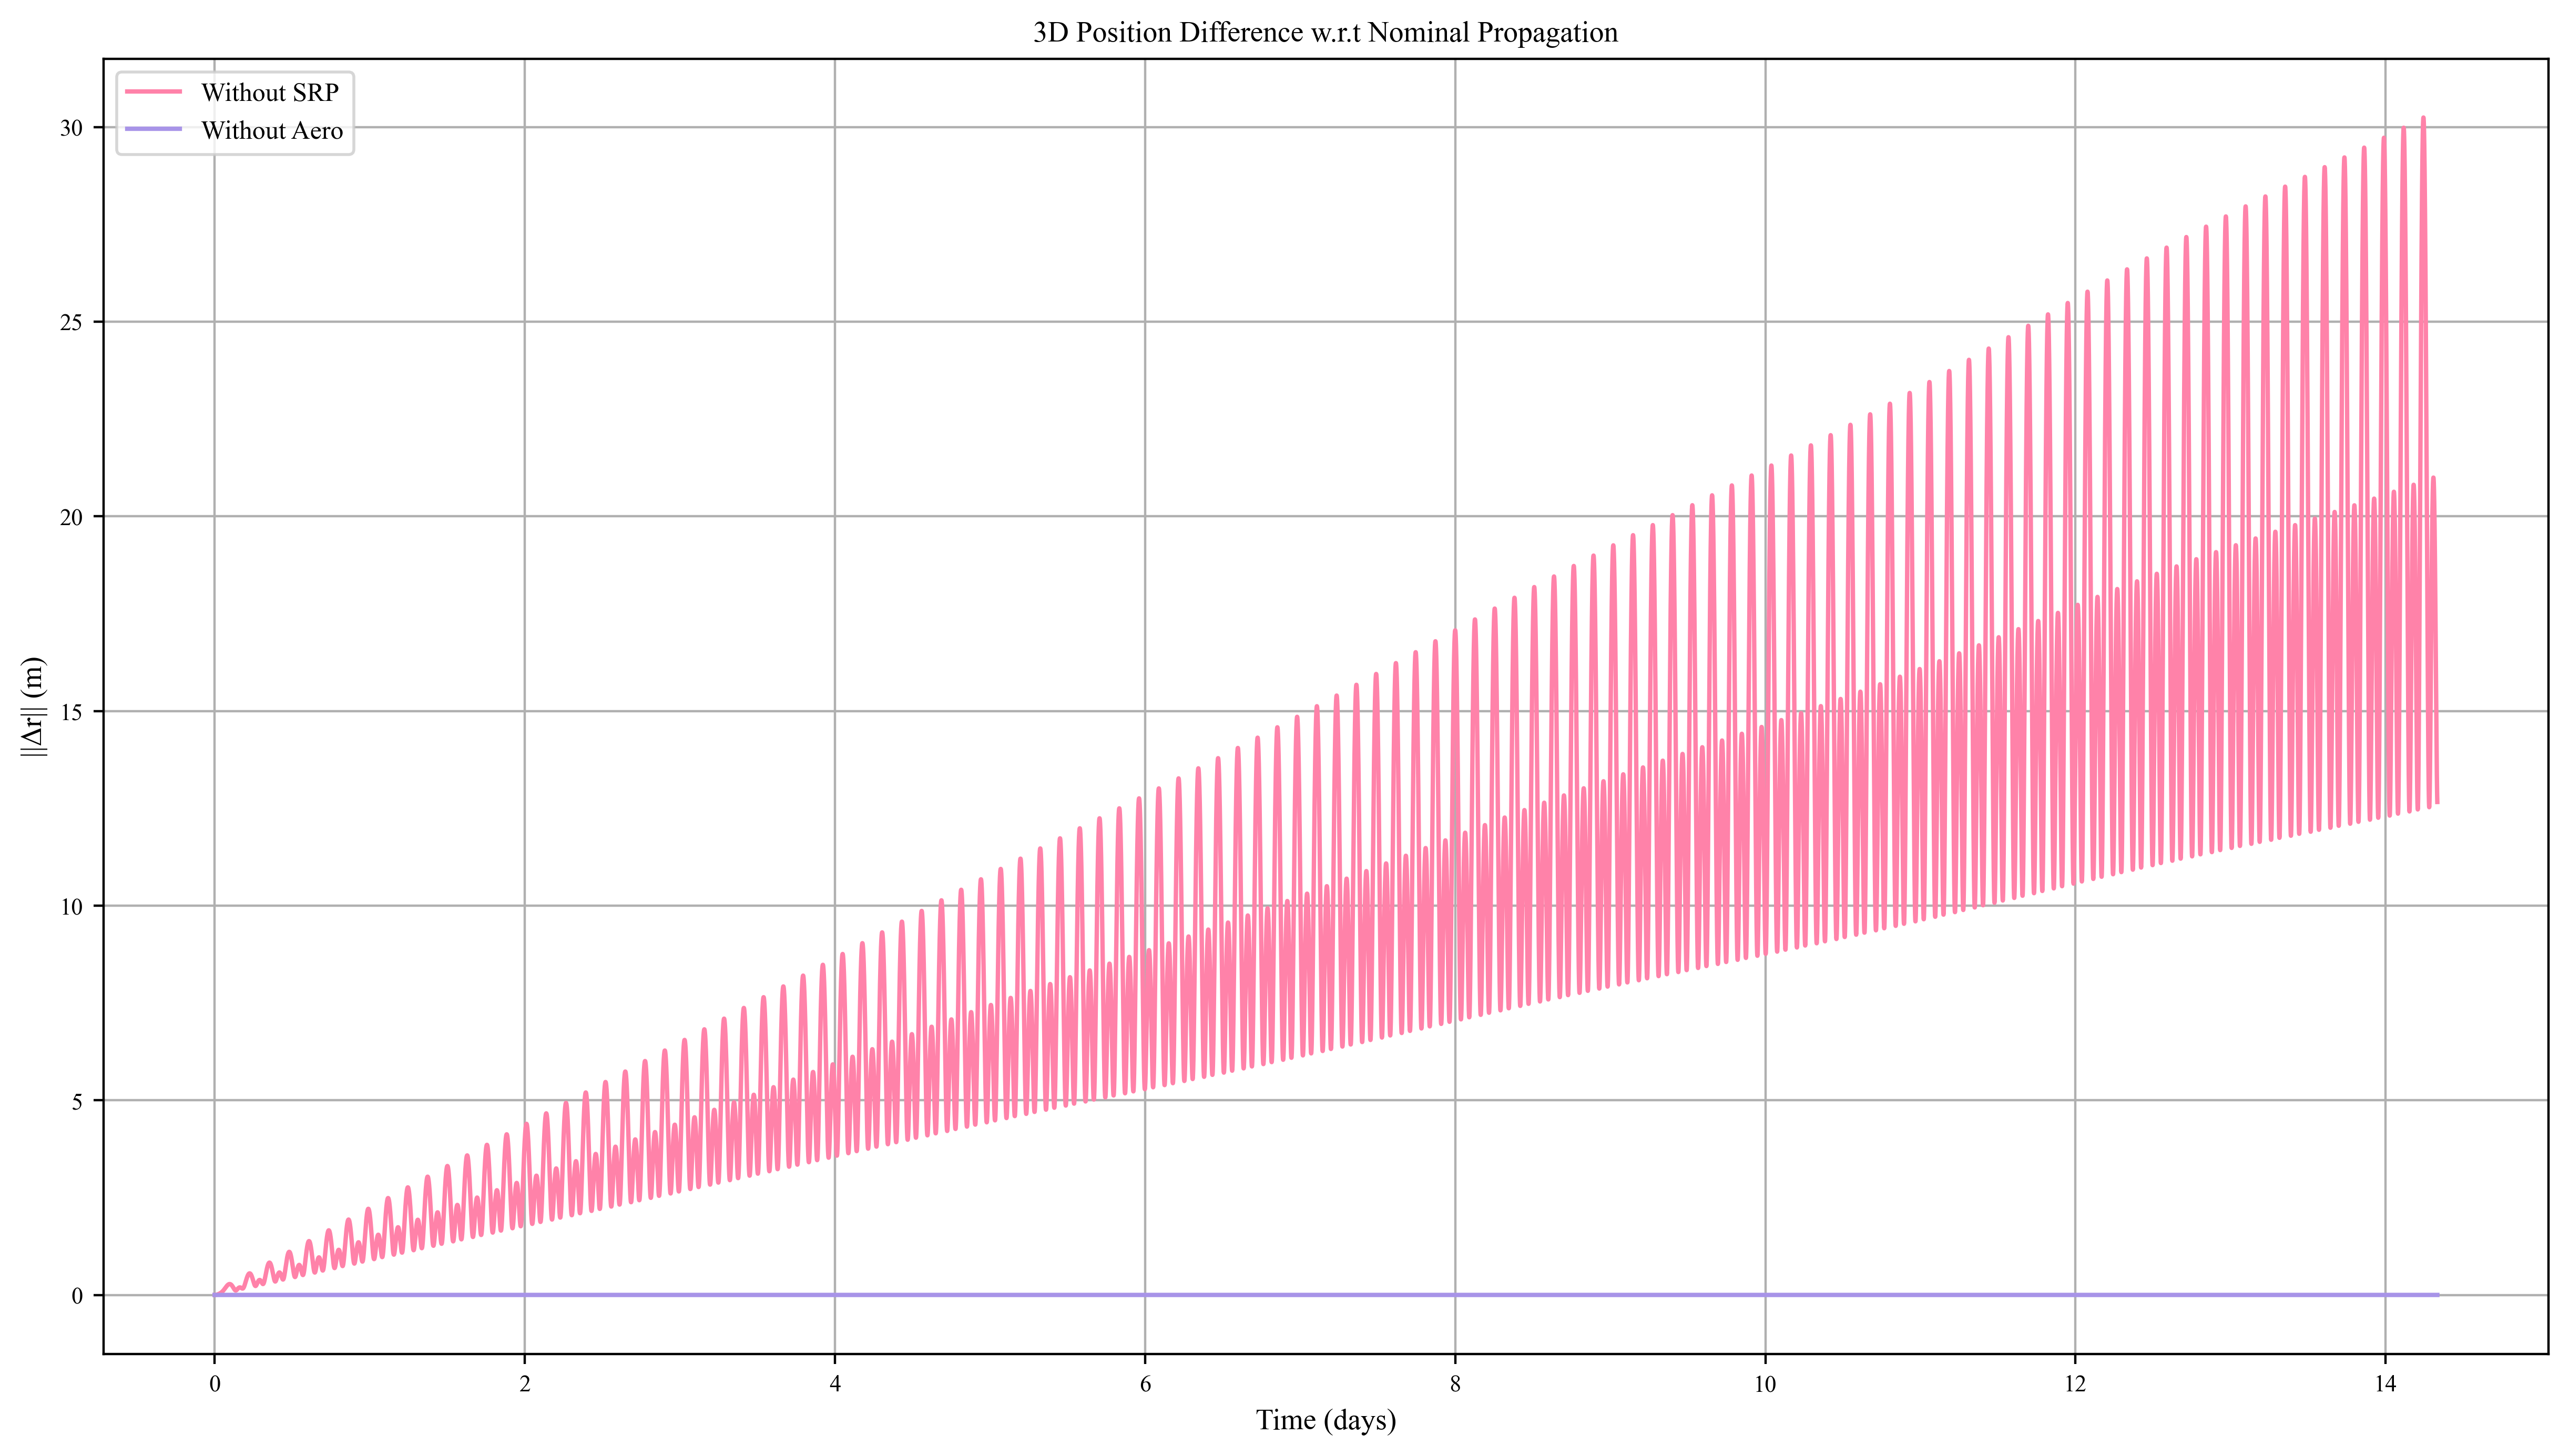

In [205]:
fig, ax = plt.subplots(figsize=(15, 8), dpi=400)

# Position vectors
r_nom  = results_nominal_case['r'][:, 0:3]
r_aero = results_aero_case['r'][:, 0:3]
r_srp  = results_srp_case['r'][:, 0:3]

# Differences
delta_r_aero = r_aero - r_nom
delta_r_srp  = r_srp  - r_nom

# Norms
norm_delta_r_aero = np.linalg.norm(delta_r_aero, axis=1)
norm_delta_r_srp  = np.linalg.norm(delta_r_srp, axis=1)

# Plot both on same axes
ax.plot(results_nominal_case['time_days'],
        norm_delta_r_aero,
        label="Without SRP",
        color=palette["pastel_pink"])

ax.plot(results_nominal_case['time_days'],
        norm_delta_r_srp,
        label="Without Aero",
        color=palette["pastel_purple"], linewidth = 1.5)

ax.set_xlabel("Time (days)")
ax.set_ylabel("||Δr|| (m)")
ax.set_title("3D Position Difference w.r.t Nominal Propagation")
ax.legend()
ax.grid(True)